In [ ]:
import numpy as np
import pandas as pd
from google.colab import files
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import sklearn.linear_model, sklearn.datasets

In [ ]:
#Loading the data
uploaded = files.upload()

#Reading the file
dataset = pd.read_csv("COMP1801_Coursework_Dataset.csv")

Saving COMP1801_Coursework_Dataset.csv to COMP1801_Coursework_Dataset (6).csv


In [ ]:
#Display the data
display(dataset)

,Lifespan,partType,microstructure,coolingRate,quenchTime,forgeTime,HeatTreatTime,Nickel%,Iron%,Cobalt%,Chromium%,smallDefects,largeDefects,sliverDefects,seedLocation,castType
0,1469.17,Nozzle,equiGrain,13,3.84,6.47,46.87,65.73,16.52,16.82,0.93,10,0,0,Bottom,Die
1,1793.64,Block,singleGrain,19,2.62,3.48,44.70,54.22,35.38,6.14,4.26,19,0,0,Bottom,Investment
2,700.60,Blade,equiGrain,28,0.76,1.34,9.54,51.83,35.95,8.81,3.41,35,3,0,Bottom,Investment
3,1082.10,Nozzle,colGrain,9,2.01,2.19,20.29,57.03,23.33,16.86,2.78,0,1,0,Top,Continuous
4,1838.83,Blade,colGrain,16,4.13,3.87,16.13,59.62,27.37,11.45,1.56,10,0,0,Top,Die
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1217.50,Block,singleGrain,5,1.91,8.55,34.76,68.11,20.73,7.15,4.01,0,0,0,Bottom,Investment
996,742.05,Block,singleGrain,10,0.67,7.99,46.21,51.25,32.12,12.23,4.40,1,0,0,Bottom,Investment
997,1448.26,Nozzle,equiGrain,17,3.12,7.61,59.87,54.09,33.20,9.31,3.40,16,1,0,Bottom,Investment
998,1099.10,Valve,colGrain,23,4.48,2.39,17.72,50.32,31.92,13.01,4.75,11,0,0,Top,Continuous


In [ ]:
print('Shape of the data (rows and columns):')
print(dataset.shape)
print()
print('First 5 rows of the data:')
print(dataset.head())
print()
print('Last 5 rows of the data:')
print(dataset.tail())
print()
print('List of the column names:')
print(dataset.columns)
print()
print('The data type of all the columns:')
print(dataset.dtypes)
print()
print('Summary of the data:')
print(dataset.describe())

Shape of the data (rows and columns):
(1000, 16)

First 5 rows of the data:
   Lifespan partType microstructure  coolingRate  quenchTime  forgeTime  \
0   1469.17   Nozzle      equiGrain           13        3.84       6.47   
1   1793.64    Block    singleGrain           19        2.62       3.48   
2    700.60    Blade      equiGrain           28        0.76       1.34   
3   1082.10   Nozzle       colGrain            9        2.01       2.19   
4   1838.83    Blade       colGrain           16        4.13       3.87   

   HeatTreatTime  Nickel%  Iron%  Cobalt%  Chromium%  smallDefects  \
0          46.87    65.73  16.52    16.82       0.93            10   
1          44.70    54.22  35.38     6.14       4.26            19   
2           9.54    51.83  35.95     8.81       3.41            35   
3          20.29    57.03  23.33    16.86       2.78             0   
4          16.13    59.62  27.37    11.45       1.56            10   

   largeDefects  sliverDefects seedLocation    castT

array([[<Axes: title={'center': 'Lifespan'}>,
        <Axes: title={'center': 'coolingRate'}>,
        <Axes: title={'center': 'quenchTime'}>],
       [<Axes: title={'center': 'forgeTime'}>,
        <Axes: title={'center': 'HeatTreatTime'}>,
        <Axes: title={'center': 'Nickel%'}>],
       [<Axes: title={'center': 'Iron%'}>,
        <Axes: title={'center': 'Cobalt%'}>,
        <Axes: title={'center': 'Chromium%'}>],
       [<Axes: title={'center': 'smallDefects'}>,
        <Axes: title={'center': 'largeDefects'}>,
        <Axes: title={'center': 'sliverDefects'}>]], dtype=object)

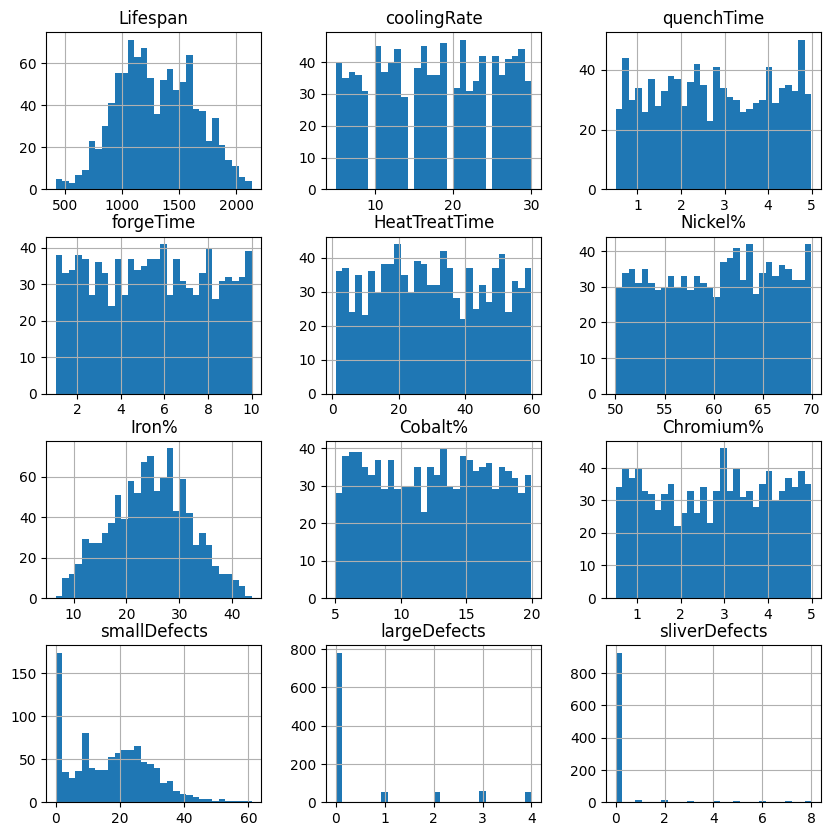

In [ ]:
num_list = ['Lifespan', 'coolingRate', 'quenchTime', 'forgeTime', 'HeatTreatTime', 'Nickel%', 'Iron%', 'Cobalt%', 'Chromium%', 'smallDefects', 'largeDefects', 'sliverDefects']

dataset[num_list].hist(bins=30, figsize=(10, 10))

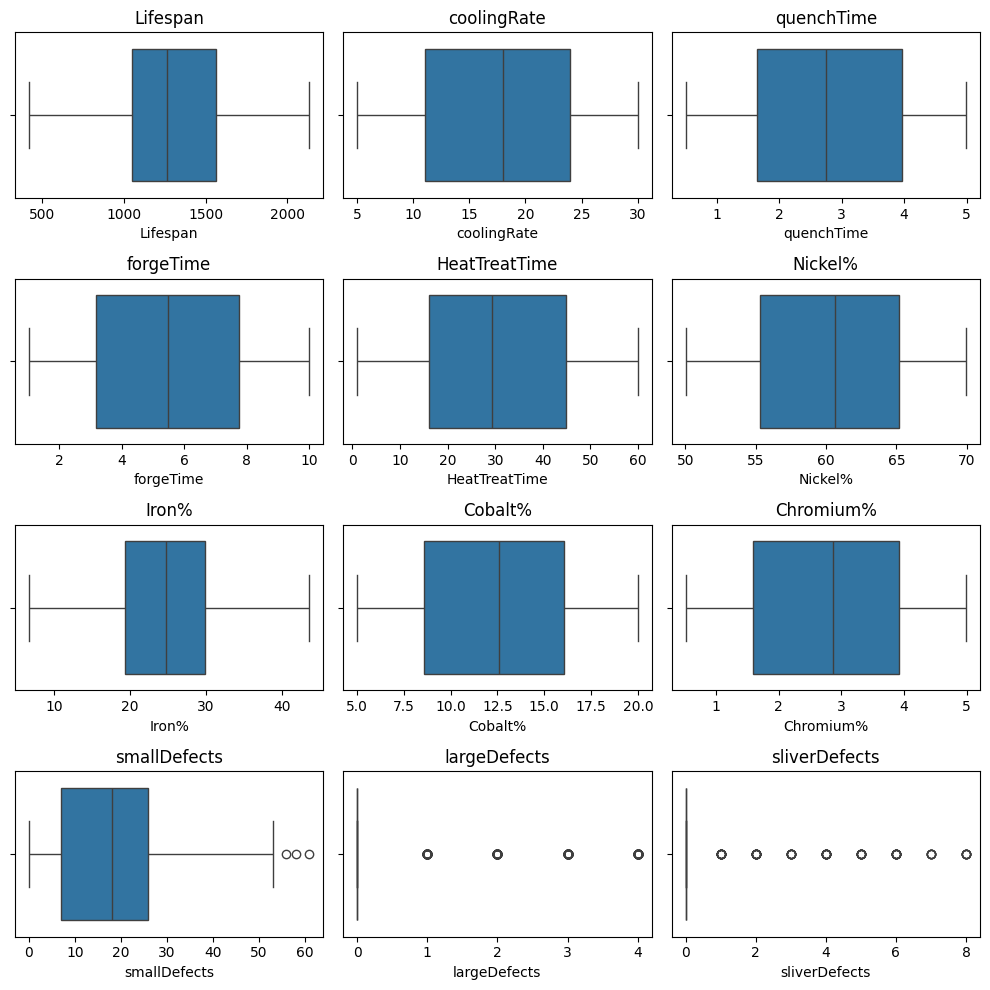

In [ ]:
plt.figure(figsize=(10, 10)) # Adjust figure size as needed

# Loop through the numerical features and create a boxplot for each
for i, column in enumerate(num_list, 1):
    plt.subplot(4, 3, i)  # 4 rows, 3 columns of plots
    sns.boxplot(data=dataset, x=column)
    plt.title(column)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [ ]:
dataset['partType'].unique()

array(['Nozzle', 'Block', 'Blade', 'Valve'], dtype=object)

In [ ]:
dataset['microstructure'].unique()

array(['equiGrain', 'singleGrain', 'colGrain'], dtype=object)

In [ ]:
dataset['seedLocation'].unique()

array(['Bottom', 'Top'], dtype=object)

In [ ]:
dataset['castType'].unique()

array(['Die', 'Investment', 'Continuous'], dtype=object)

#ENCODING

In [ ]:
partType_OHE = dataset.copy()

oneHotEncoder = OneHotEncoder()

onehot_enc = oneHotEncoder.fit(partType_OHE[['partType']])
print('The categories are: ', onehot_enc.categories_)

OHT = onehot_enc.transform(partType_OHE[['partType']]).toarray()

partType_OHE['partTypeNozzle'] = OHT[:,0]
partType_OHE['partTypeBlock'] = OHT[:,1]
partType_OHE['partTypeBlade'] = OHT[:,2]
partType_OHE['partTypeValve'] = OHT[:,3]

(partType_OHE)


The categories are:  [array(['Blade', 'Block', 'Nozzle', 'Valve'], dtype=object)]


,Lifespan,partType,microstructure,coolingRate,quenchTime,forgeTime,HeatTreatTime,Nickel%,Iron%,Cobalt%,Chromium%,smallDefects,largeDefects,sliverDefects,seedLocation,castType,partTypeNozzle,partTypeBlock,partTypeBlade,partTypeValve
0,1469.17,Nozzle,equiGrain,13,3.84,6.47,46.87,65.73,16.52,16.82,0.93,10,0,0,Bottom,Die,0.0,0.0,1.0,0.0
1,1793.64,Block,singleGrain,19,2.62,3.48,44.70,54.22,35.38,6.14,4.26,19,0,0,Bottom,Investment,0.0,1.0,0.0,0.0
2,700.60,Blade,equiGrain,28,0.76,1.34,9.54,51.83,35.95,8.81,3.41,35,3,0,Bottom,Investment,1.0,0.0,0.0,0.0
3,1082.10,Nozzle,colGrain,9,2.01,2.19,20.29,57.03,23.33,16.86,2.78,0,1,0,Top,Continuous,0.0,0.0,1.0,0.0
4,1838.83,Blade,colGrain,16,4.13,3.87,16.13,59.62,27.37,11.45,1.56,10,0,0,Top,Die,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1217.50,Block,singleGrain,5,1.91,8.55,34.76,68.11,20.73,7.15,4.01,0,0,0,Bottom,Investment,0.0,1.0,0.0,0.0
996,742.05,Block,singleGrain,10,0.67,7.99,46.21,51.25,32.12,12.23,4.40,1,0,0,Bottom,Investment,0.0,1.0,0.0,0.0
997,1448.26,Nozzle,equiGrain,17,3.12,7.61,59.87,54.09,33.20,9.31,3.40,16,1,0,Bottom,Investment,0.0,0.0,1.0,0.0
998,1099.10,Valve,colGrain,23,4.48,2.39,17.72,50.32,31.92,13.01,4.75,11,0,0,Top,Continuous,0.0,0.0,0.0,1.0


In [ ]:
microstructure_OHE = partType_OHE.copy()

oneHotEncoder = OneHotEncoder()

onehot_enc = oneHotEncoder.fit(microstructure_OHE[['microstructure']])
print('The categories are: ', onehot_enc.categories_)

OHT = onehot_enc.transform(microstructure_OHE[['microstructure']]).toarray()

microstructure_OHE['microstructureEquiGrain'] = OHT[:,0]
microstructure_OHE['microstructureSingleGrain'] = OHT[:,1]
microstructure_OHE['microstructureColGrain'] = OHT[:,2]

display(microstructure_OHE)

The categories are:  [array(['colGrain', 'equiGrain', 'singleGrain'], dtype=object)]


,Lifespan,partType,microstructure,coolingRate,quenchTime,forgeTime,HeatTreatTime,Nickel%,Iron%,Cobalt%,...,sliverDefects,seedLocation,castType,partTypeNozzle,partTypeBlock,partTypeBlade,partTypeValve,microstructureEquiGrain,microstructureSingleGrain,microstructureColGrain
0,1469.17,Nozzle,equiGrain,13,3.84,6.47,46.87,65.73,16.52,16.82,...,0,Bottom,Die,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1793.64,Block,singleGrain,19,2.62,3.48,44.70,54.22,35.38,6.14,...,0,Bottom,Investment,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,700.60,Blade,equiGrain,28,0.76,1.34,9.54,51.83,35.95,8.81,...,0,Bottom,Investment,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1082.10,Nozzle,colGrain,9,2.01,2.19,20.29,57.03,23.33,16.86,...,0,Top,Continuous,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,1838.83,Blade,colGrain,16,4.13,3.87,16.13,59.62,27.37,11.45,...,0,Top,Die,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1217.50,Block,singleGrain,5,1.91,8.55,34.76,68.11,20.73,7.15,...,0,Bottom,Investment,0.0,1.0,0.0,0.0,0.0,0.0,1.0
996,742.05,Block,singleGrain,10,0.67,7.99,46.21,51.25,32.12,12.23,...,0,Bottom,Investment,0.0,1.0,0.0,0.0,0.0,0.0,1.0
997,1448.26,Nozzle,equiGrain,17,3.12,7.61,59.87,54.09,33.20,9.31,...,0,Bottom,Investment,0.0,0.0,1.0,0.0,0.0,1.0,0.0
998,1099.10,Valve,colGrain,23,4.48,2.39,17.72,50.32,31.92,13.01,...,0,Top,Continuous,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [ ]:
seedLocation_OHE = microstructure_OHE.copy()

oneHotEncoder = OneHotEncoder()

onehot_enc = oneHotEncoder.fit(seedLocation_OHE[['seedLocation']])
print('The categories are: ', onehot_enc.categories_)

OHT = onehot_enc.transform(seedLocation_OHE[['seedLocation']]).toarray()

seedLocation_OHE['seedLocationBottom'] = OHT[:,0]
seedLocation_OHE['seedLocationTop'] = OHT[:,1]


display(seedLocation_OHE)

The categories are:  [array(['Bottom', 'Top'], dtype=object)]


,Lifespan,partType,microstructure,coolingRate,quenchTime,forgeTime,HeatTreatTime,Nickel%,Iron%,Cobalt%,...,castType,partTypeNozzle,partTypeBlock,partTypeBlade,partTypeValve,microstructureEquiGrain,microstructureSingleGrain,microstructureColGrain,seedLocationBottom,seedLocationTop
0,1469.17,Nozzle,equiGrain,13,3.84,6.47,46.87,65.73,16.52,16.82,...,Die,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1793.64,Block,singleGrain,19,2.62,3.48,44.70,54.22,35.38,6.14,...,Investment,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,700.60,Blade,equiGrain,28,0.76,1.34,9.54,51.83,35.95,8.81,...,Investment,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,1082.10,Nozzle,colGrain,9,2.01,2.19,20.29,57.03,23.33,16.86,...,Continuous,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,1838.83,Blade,colGrain,16,4.13,3.87,16.13,59.62,27.37,11.45,...,Die,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1217.50,Block,singleGrain,5,1.91,8.55,34.76,68.11,20.73,7.15,...,Investment,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
996,742.05,Block,singleGrain,10,0.67,7.99,46.21,51.25,32.12,12.23,...,Investment,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
997,1448.26,Nozzle,equiGrain,17,3.12,7.61,59.87,54.09,33.20,9.31,...,Investment,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
998,1099.10,Valve,colGrain,23,4.48,2.39,17.72,50.32,31.92,13.01,...,Continuous,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
castType_OHE = seedLocation_OHE.copy()

oneHotEncoder = OneHotEncoder()

onehot_enc = oneHotEncoder.fit(castType_OHE[['castType']])
print('The categories are: ', onehot_enc.categories_)

OHT = onehot_enc.transform(castType_OHE[['castType']]).toarray()

castType_OHE['castTypeDie'] = OHT[:,0]
castType_OHE['castTypeInvestment'] = OHT[:,1]
castType_OHE['castTypeContinuous'] = OHT[:,2]

display(castType_OHE)

The categories are:  [array(['Continuous', 'Die', 'Investment'], dtype=object)]


,Lifespan,partType,microstructure,coolingRate,quenchTime,forgeTime,HeatTreatTime,Nickel%,Iron%,Cobalt%,...,partTypeBlade,partTypeValve,microstructureEquiGrain,microstructureSingleGrain,microstructureColGrain,seedLocationBottom,seedLocationTop,castTypeDie,castTypeInvestment,castTypeContinuous
0,1469.17,Nozzle,equiGrain,13,3.84,6.47,46.87,65.73,16.52,16.82,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1793.64,Block,singleGrain,19,2.62,3.48,44.70,54.22,35.38,6.14,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
2,700.60,Blade,equiGrain,28,0.76,1.34,9.54,51.83,35.95,8.81,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1082.10,Nozzle,colGrain,9,2.01,2.19,20.29,57.03,23.33,16.86,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,1838.83,Blade,colGrain,16,4.13,3.87,16.13,59.62,27.37,11.45,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1217.50,Block,singleGrain,5,1.91,8.55,34.76,68.11,20.73,7.15,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
996,742.05,Block,singleGrain,10,0.67,7.99,46.21,51.25,32.12,12.23,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
997,1448.26,Nozzle,equiGrain,17,3.12,7.61,59.87,54.09,33.20,9.31,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
998,1099.10,Valve,colGrain,23,4.48,2.39,17.72,50.32,31.92,13.01,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [ ]:
castType_OHE = castType_OHE.drop(['partType', 'microstructure', 'seedLocation', 'castType'], axis = 1)

enc_df = castType_OHE.copy()
display(enc_df)

,Lifespan,coolingRate,quenchTime,forgeTime,HeatTreatTime,Nickel%,Iron%,Cobalt%,Chromium%,smallDefects,...,partTypeBlade,partTypeValve,microstructureEquiGrain,microstructureSingleGrain,microstructureColGrain,seedLocationBottom,seedLocationTop,castTypeDie,castTypeInvestment,castTypeContinuous
0,1469.17,13,3.84,6.47,46.87,65.73,16.52,16.82,0.93,10,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1793.64,19,2.62,3.48,44.70,54.22,35.38,6.14,4.26,19,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
2,700.60,28,0.76,1.34,9.54,51.83,35.95,8.81,3.41,35,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1082.10,9,2.01,2.19,20.29,57.03,23.33,16.86,2.78,0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,1838.83,16,4.13,3.87,16.13,59.62,27.37,11.45,1.56,10,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1217.50,5,1.91,8.55,34.76,68.11,20.73,7.15,4.01,0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
996,742.05,10,0.67,7.99,46.21,51.25,32.12,12.23,4.40,1,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
997,1448.26,17,3.12,7.61,59.87,54.09,33.20,9.31,3.40,16,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
998,1099.10,23,4.48,2.39,17.72,50.32,31.92,13.01,4.75,11,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [ ]:
scaler = StandardScaler()

# Fit the scaler to the numerical features and transform them
enc_df_scaled = scaler.fit_transform(enc_df)

# Convert the scaled array back to a DataFrame with original column names
enc_df_scaled = pd.DataFrame(enc_df_scaled, columns=enc_df.columns)

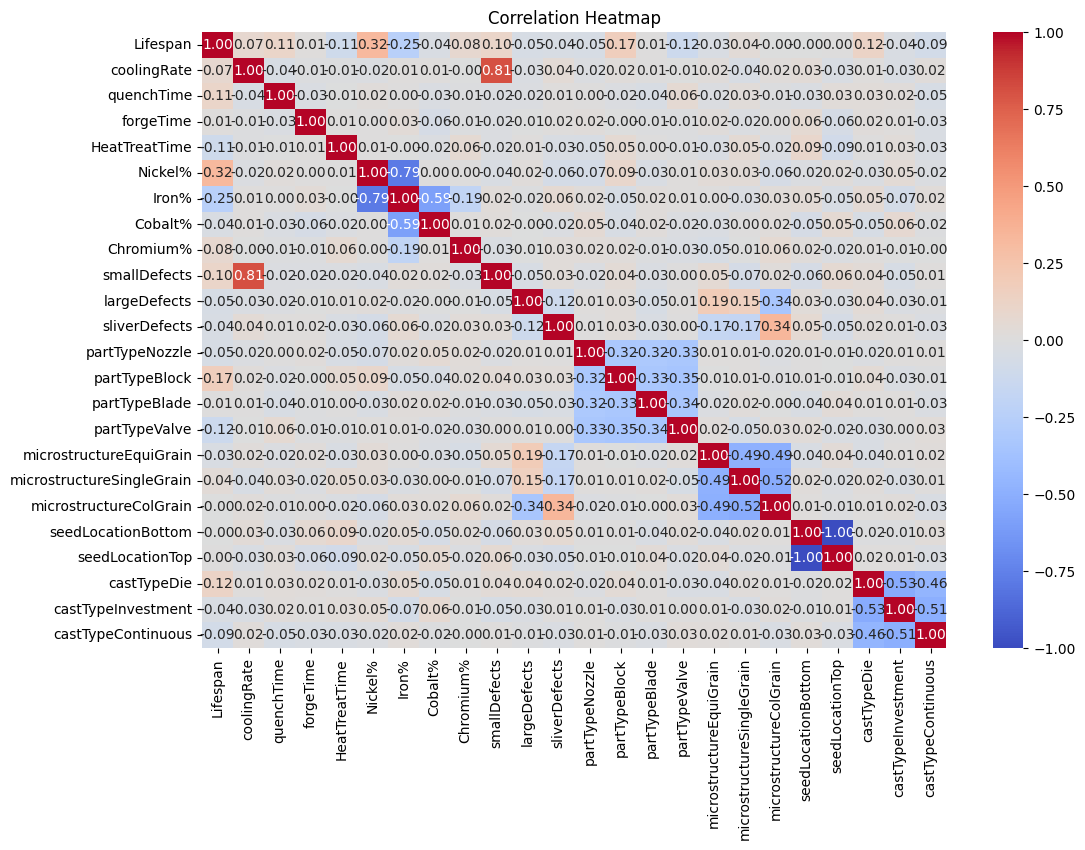

In [ ]:
correlation_matrix = enc_df_scaled.corr()
# Set the figure size
plt.figure(figsize=(12, 8))

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Set the title
plt.title('Correlation Heatmap')

# Show the plot
plt.show()

In [ ]:
print(enc_df_scaled.columns)

Index(['Lifespan', 'coolingRate', 'quenchTime', 'forgeTime', 'HeatTreatTime',
       'Nickel%', 'Iron%', 'Cobalt%', 'Chromium%', 'smallDefects',
       'largeDefects', 'sliverDefects', 'partTypeNozzle', 'partTypeBlock',
       'partTypeBlade', 'partTypeValve', 'microstructureEquiGrain',
       'microstructureSingleGrain', 'microstructureColGrain',
       'seedLocationBottom', 'seedLocationTop', 'castTypeDie',
       'castTypeInvestment', 'castTypeContinuous'],
      dtype='object')


#PCA

In [ ]:
merge = enc_df_scaled[['coolingRate', 'smallDefects']]


pca = PCA(n_components=1)  # Keeps enough components to explain 100% of the variance
principal_components = pca.fit_transform(merge)

# Create a DataFrame with principal components
df_pca = pd.DataFrame(principal_components, columns = [['PCA_1']])

enc_df_scaled = enc_df_scaled.drop(['coolingRate', 'smallDefects'], axis = 1)
enc_df_scaled['PCA_1'] = df_pca

#Display
print(enc_df_scaled.head())

   Lifespan  quenchTime  forgeTime  HeatTreatTime   Nickel%     Iron%  \
0  0.501951    0.817256   0.386215       0.987828  0.948051 -1.090327   
1  1.456551   -0.109571  -0.762366       0.859281 -1.040691  1.469374   
2 -1.759205   -1.522601  -1.584428      -1.223538 -1.453644  1.546735   
3 -0.636821   -0.572984  -1.257908      -0.586726 -0.555168 -0.166066   
4  1.589501    1.037567  -0.612551      -0.833158 -0.107658  0.382248   

    Cobalt%  Chromium%  largeDefects  sliverDefects  ...  partTypeValve  \
0  1.012533  -1.386789     -0.472752       -0.24361  ...      -0.600453   
1 -1.453393   1.124840     -0.472752       -0.24361  ...      -0.600453   
2 -0.836912   0.483734      2.105896       -0.24361  ...      -0.600453   
3  1.021768   0.008561      0.386797       -0.24361  ...      -0.600453   
4 -0.227357  -0.911616     -0.472752       -0.24361  ...      -0.600453   

   microstructureEquiGrain  microstructureSingleGrain  microstructureColGrain  \
0                -0.681270   

In [ ]:
merge = enc_df_scaled[['Nickel%', 'Iron%']]


pca = PCA(n_components=1)  # Keeps enough components to explain 100% of the variance
principal_components = pca.fit_transform(merge)

# Create a DataFrame with principal components
df_pca = pd.DataFrame(principal_components, columns = [['PCA_2']])

enc_df_scaled = enc_df_scaled.drop(['Nickel%', 'Iron%'], axis = 1)
enc_df_scaled['PCA_2'] = df_pca

#Display
print(enc_df_scaled.head())

   Lifespan  quenchTime  forgeTime  HeatTreatTime   Cobalt%  Chromium%  \
0  0.501951    0.817256   0.386215       0.987828  1.012533  -1.386789   
1  1.456551   -0.109571  -0.762366       0.859281 -1.453393   1.124840   
2 -1.759205   -1.522601  -1.584428      -1.223538 -0.836912   0.483734   
3 -0.636821   -0.572984  -1.257908      -0.586726  1.021768   0.008561   
4  1.589501    1.037567  -0.612551      -0.833158 -0.227357  -0.911616   

   largeDefects  sliverDefects  partTypeNozzle  partTypeBlock  ...  \
0     -0.472752       -0.24361       -0.557329      -0.581969  ...   
1     -0.472752       -0.24361       -0.557329       1.718304  ...   
2      2.105896       -0.24361        1.794271      -0.581969  ...   
3      0.386797       -0.24361       -0.557329      -0.581969  ...   
4     -0.472752       -0.24361        1.794271      -0.581969  ...   

   microstructureEquiGrain  microstructureSingleGrain  microstructureColGrain  \
0                -0.681270                   1.393261

In [ ]:
merge = enc_df_scaled[['partTypeNozzle', 'partTypeBlock', 'partTypeBlade', 'partTypeValve']]


pca = PCA(n_components=1)  # Keeps enough components to explain 100% of the variance
principal_components = pca.fit_transform(merge)

# Create a DataFrame with principal components
df_pca = pd.DataFrame(principal_components, columns = [['PCA_3']])

enc_df_scaled = enc_df_scaled.drop(['partTypeNozzle', 'partTypeBlock', 'partTypeBlade', 'partTypeValve'], axis = 1)
enc_df_scaled['PCA_3'] = df_pca

#Display
print(enc_df_scaled.head())

   Lifespan  quenchTime  forgeTime  HeatTreatTime   Cobalt%  Chromium%  \
0  0.501951    0.817256   0.386215       0.987828  1.012533  -1.386789   
1  1.456551   -0.109571  -0.762366       0.859281 -1.453393   1.124840   
2 -1.759205   -1.522601  -1.584428      -1.223538 -0.836912   0.483734   
3 -0.636821   -0.572984  -1.257908      -0.586726  1.021768   0.008561   
4  1.589501    1.037567  -0.612551      -0.833158 -0.227357  -0.911616   

   largeDefects  sliverDefects  microstructureEquiGrain  \
0     -0.472752       -0.24361                -0.681270   
1     -0.472752       -0.24361                -0.681270   
2      2.105896       -0.24361                -0.681270   
3      0.386797       -0.24361                 1.467847   
4     -0.472752       -0.24361                 1.467847   

   microstructureSingleGrain  microstructureColGrain  seedLocationBottom  \
0                   1.393261               -0.722544            1.006018   
1                  -0.717741                1.38

In [ ]:
merge = enc_df_scaled[['microstructureEquiGrain', 'microstructureSingleGrain', 'microstructureColGrain']]


pca = PCA(n_components=1)  # Keeps enough components to explain 100% of the variance
principal_components = pca.fit_transform(merge)

# Create a DataFrame with principal components
df_pca = pd.DataFrame(principal_components, columns = [['PCA_4']])

enc_df_scaled = enc_df_scaled.drop(['microstructureEquiGrain', 'microstructureSingleGrain', 'microstructureColGrain'], axis = 1)
enc_df_scaled['PCA_4'] = df_pca

#Display
print(enc_df_scaled.head())

   Lifespan  quenchTime  forgeTime  HeatTreatTime   Cobalt%  Chromium%  \
0  0.501951    0.817256   0.386215       0.987828  1.012533  -1.386789   
1  1.456551   -0.109571  -0.762366       0.859281 -1.453393   1.124840   
2 -1.759205   -1.522601  -1.584428      -1.223538 -0.836912   0.483734   
3 -0.636821   -0.572984  -1.257908      -0.586726  1.021768   0.008561   
4  1.589501    1.037567  -0.612551      -0.833158 -0.227357  -0.911616   

   largeDefects  sliverDefects  seedLocationBottom  seedLocationTop  \
0     -0.472752       -0.24361            1.006018        -1.006018   
1     -0.472752       -0.24361            1.006018        -1.006018   
2      2.105896       -0.24361            1.006018        -1.006018   
3      0.386797       -0.24361           -0.994018         0.994018   
4     -0.472752       -0.24361           -0.994018         0.994018   

   castTypeDie  castTypeInvestment  castTypeContinuous     PCA_1     PCA_2  \
0    -0.697054            1.316146           -0.66

In [ ]:
merge = enc_df_scaled[['seedLocationBottom', 'seedLocationTop']]


pca = PCA(n_components=1)  # Keeps enough components to explain 100% of the variance
principal_components = pca.fit_transform(merge)

# Create a DataFrame with principal components
df_pca = pd.DataFrame(principal_components, columns = [['PCA_5']])

enc_df_scaled = enc_df_scaled.drop(['seedLocationBottom', 'seedLocationTop'], axis = 1)
enc_df_scaled['PCA_5'] = df_pca

#Display
print(enc_df_scaled.head())

   Lifespan  quenchTime  forgeTime  HeatTreatTime   Cobalt%  Chromium%  \
0  0.501951    0.817256   0.386215       0.987828  1.012533  -1.386789   
1  1.456551   -0.109571  -0.762366       0.859281 -1.453393   1.124840   
2 -1.759205   -1.522601  -1.584428      -1.223538 -0.836912   0.483734   
3 -0.636821   -0.572984  -1.257908      -0.586726  1.021768   0.008561   
4  1.589501    1.037567  -0.612551      -0.833158 -0.227357  -0.911616   

   largeDefects  sliverDefects  castTypeDie  castTypeInvestment  \
0     -0.472752       -0.24361    -0.697054            1.316146   
1     -0.472752       -0.24361    -0.697054           -0.759794   
2      2.105896       -0.24361    -0.697054           -0.759794   
3      0.386797       -0.24361     1.434609           -0.759794   
4     -0.472752       -0.24361    -0.697054            1.316146   

   castTypeContinuous     PCA_1     PCA_2     PCA_3     PCA_4     PCA_5  
0           -0.665584 -0.859660 -1.441351 -0.544280 -1.451902  1.422724  
1   

In [ ]:
merge = enc_df_scaled[['castTypeDie', 'castTypeInvestment', 'castTypeContinuous']]


pca = PCA(n_components=1)  # Keeps enough components to explain 100% of the variance
principal_components = pca.fit_transform(merge)

# Create a DataFrame with principal components
df_pca = pd.DataFrame(principal_components, columns = [['PCA_6']])

enc_df_scaled = enc_df_scaled.drop(['castTypeDie', 'castTypeInvestment', 'castTypeContinuous'], axis = 1)
enc_df_scaled['PCA_6'] = df_pca

#Display
print(enc_df_scaled.head())

   Lifespan  quenchTime  forgeTime  HeatTreatTime   Cobalt%  Chromium%  \
0  0.501951    0.817256   0.386215       0.987828  1.012533  -1.386789   
1  1.456551   -0.109571  -0.762366       0.859281 -1.453393   1.124840   
2 -1.759205   -1.522601  -1.584428      -1.223538 -0.836912   0.483734   
3 -0.636821   -0.572984  -1.257908      -0.586726  1.021768   0.008561   
4  1.589501    1.037567  -0.612551      -0.833158 -0.227357  -0.911616   

   largeDefects  sliverDefects     PCA_1     PCA_2     PCA_3     PCA_4  \
0     -0.472752       -0.24361 -0.859660 -1.441351 -0.544280 -1.451902   
1     -0.472752       -0.24361  0.225918  1.774884 -1.104749  1.526395   
2      2.105896       -0.24361  1.998449  2.121588 -0.363656 -1.451902   
3      0.386797       -0.24361 -1.814040  0.275137 -0.544280 -0.094342   
4     -0.472752       -0.24361 -0.576365  0.346416 -0.363656 -0.094342   

      PCA_5     PCA_6  
0  1.422724  1.608454  
1  1.422724 -0.653673  
2  1.422724 -0.653673  
3 -1.405754 -1

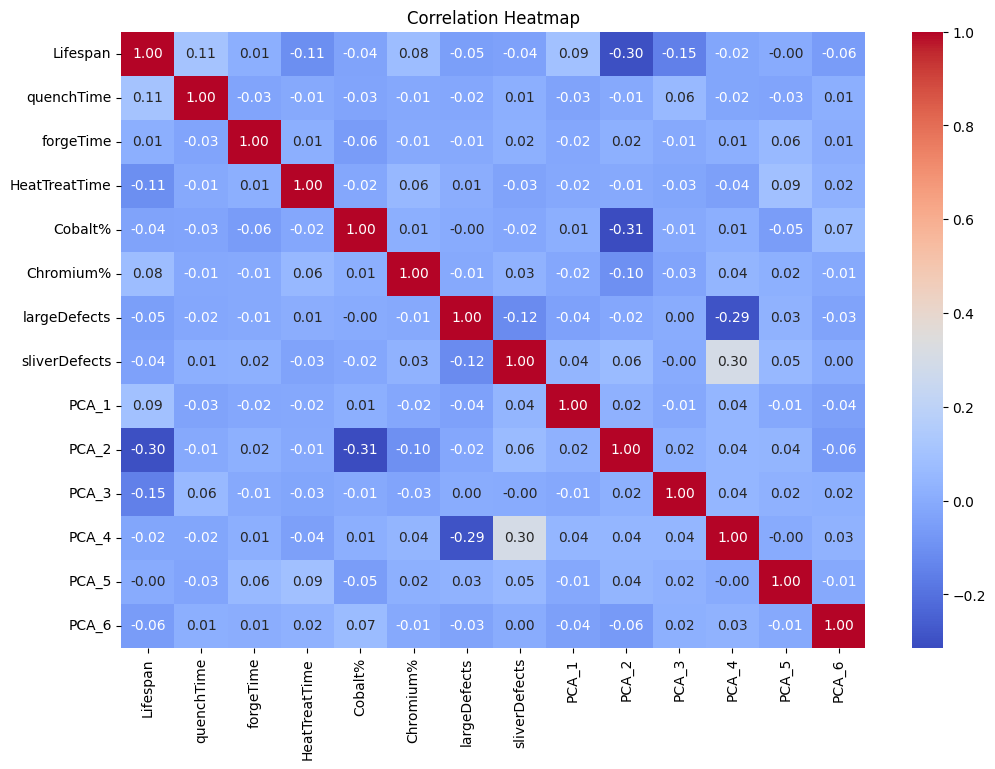

In [ ]:
correlation_matrix = enc_df_scaled.corr()
# Set the figure size
plt.figure(figsize=(12, 8))

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Set the title
plt.title('Correlation Heatmap')

# Show the plot
plt.show()

In [ ]:
merge = enc_df_scaled[['Cobalt%', 'PCA_2']]


pca = PCA(n_components=1)  # Keeps enough components to explain 100% of the variance
principal_components = pca.fit_transform(merge)

# Create a DataFrame with principal components
df_pca = pd.DataFrame(principal_components, columns = [['PCA_C_2']])

enc_df_scaled = enc_df_scaled.drop(['Cobalt%', 'PCA_2'], axis = 1)
enc_df_scaled['PCA_C_2'] = df_pca

#Display
print(enc_df_scaled.head())

   Lifespan  quenchTime  forgeTime  HeatTreatTime  Chromium%  largeDefects  \
0  0.501951    0.817256   0.386215       0.987828  -1.386789     -0.472752   
1  1.456551   -0.109571  -0.762366       0.859281   1.124840     -0.472752   
2 -1.759205   -1.522601  -1.584428      -1.223538   0.483734      2.105896   
3 -0.636821   -0.572984  -1.257908      -0.586726   0.008561      0.386797   
4  1.589501    1.037567  -0.612551      -0.833158  -0.911616     -0.472752   

   sliverDefects     PCA_1     PCA_3     PCA_4     PCA_5     PCA_6   PCA_C_2  
0       -0.24361 -0.859660 -0.544280 -1.451902  1.422724  1.608454 -1.724984  
1       -0.24361  0.225918 -1.104749  1.526395  1.422724 -0.653673  2.206213  
2       -0.24361  1.998449 -0.363656 -1.451902  1.422724 -0.653673  2.279464  
3       -0.24361 -1.814040 -0.544280 -0.094342 -1.405754 -1.186595 -0.153440  
4       -0.24361 -0.576365 -0.363656 -0.094342 -1.405754  1.608454  0.408230  


In [ ]:
merge = enc_df_scaled[['sliverDefects', 'PCA_4']]


pca = PCA(n_components=1)  # Keeps enough components to explain 100% of the variance
principal_components = pca.fit_transform(merge)

# Create a DataFrame with principal components
df_pca = pd.DataFrame(principal_components, columns = [['PCA_s_4']])

enc_df_scaled = enc_df_scaled.drop(['sliverDefects', 'PCA_4'], axis = 1)
enc_df_scaled['PCA_s_4'] = df_pca

#Display
print(enc_df_scaled.head())

   Lifespan  quenchTime  forgeTime  HeatTreatTime  Chromium%  largeDefects  \
0  0.501951    0.817256   0.386215       0.987828  -1.386789     -0.472752   
1  1.456551   -0.109571  -0.762366       0.859281   1.124840     -0.472752   
2 -1.759205   -1.522601  -1.584428      -1.223538   0.483734      2.105896   
3 -0.636821   -0.572984  -1.257908      -0.586726   0.008561      0.386797   
4  1.589501    1.037567  -0.612551      -0.833158  -0.911616     -0.472752   

      PCA_1     PCA_3     PCA_5     PCA_6   PCA_C_2   PCA_s_4  
0 -0.859660 -0.544280  1.422724  1.608454 -1.724984 -1.399920  
1  0.225918 -1.104749  1.422724 -0.653673  2.206213  1.240593  
2  1.998449 -0.363656  1.422724 -0.653673  2.279464 -1.399920  
3 -1.814040 -0.544280 -1.405754 -1.186595 -0.153440 -0.196328  
4 -0.576365 -0.363656 -1.405754  1.608454  0.408230 -0.196328  


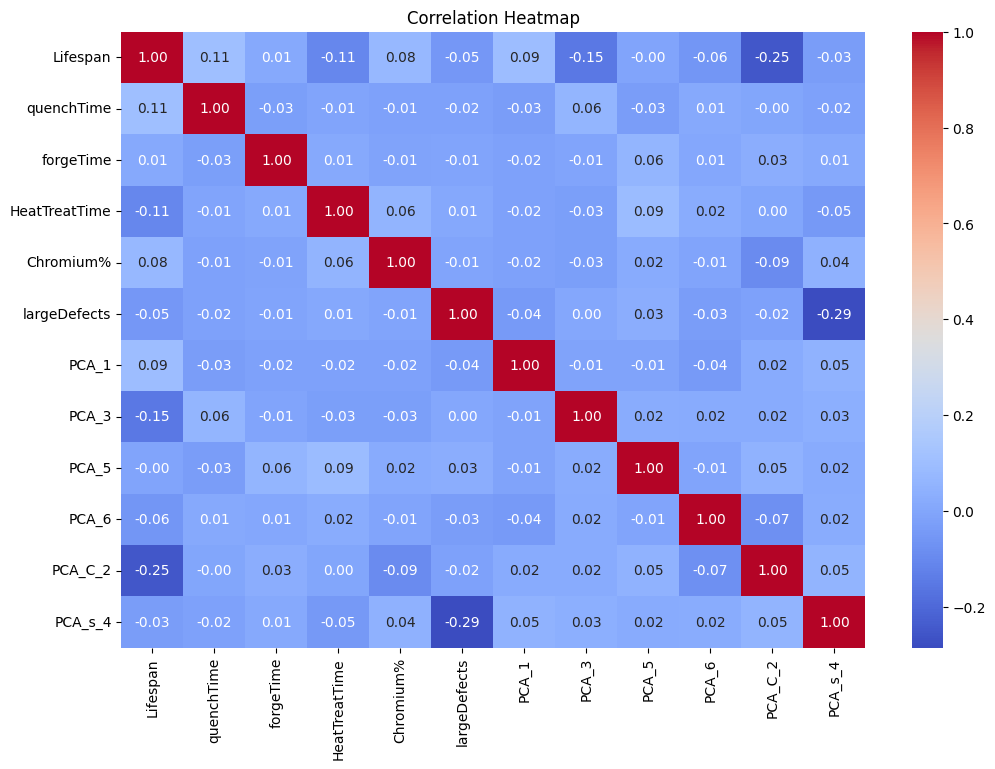

In [ ]:
correlation_matrix = enc_df_scaled.corr()
# Set the figure size
plt.figure(figsize=(12, 8))

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Set the title
plt.title('Correlation Heatmap')

# Show the plot
plt.show()

##PREDICT

In [ ]:
# Independent variables
X = enc_df_scaled[['quenchTime', 'HeatTreatTime', 'PCA_1', 'PCA_3', 'PCA_C_2']]

# Dependent variable
Y = enc_df_scaled["Lifespan"]

In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

#Polynomial Regression

In [ ]:
# Define a pipeline for Polynomial Regression
model = Pipeline([
    ('poly', PolynomialFeatures()),
    ('linear', LinearRegression())
])

# Define the hyperparameter space for Polynomial Regression
param_space = {'poly__degree': [2, 3, 4], 'linear__fit_intercept': [True, False], 'linear__n_jobs': [1, 5, None]}

grid_search = GridSearchCV(model, param_space, cv=5)
grid_search.fit(X_train, y_train)

# Predictions and evaluation
y_pred = grid_search.predict(X_test)
print(f"Best Hyperparameters for Polynomial Regression: {grid_search.best_params_}")
print(f"Best Score for Polynomial Regression: {grid_search.best_score_}")
print('Mean squared error loss:', mean_squared_error(y_test, y_pred))
print('R2 score:', r2_score(y_test, y_pred))

Best Hyperparameters for Polynomial Regression: {'linear__fit_intercept': False, 'linear__n_jobs': 1, 'poly__degree': 4}
Best Score for Polynomial Regression: 0.5924612300244464
Mean squared error loss: 0.3498012253808431
R2 score: 0.6631982749370617


#Random Forest Regression

In [ ]:
# Initialize the Random Forest Regressor
model = RandomForestRegressor()

# Define the hyperparameter search space for Random Forest
param_space = {
    'n_estimators': [100, 200, 300, 500],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],        # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],        # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],          # Minimum number of samples required to be at a leaf node
    'n_jobs': [1, 4, 8, -1],                # Number of jobs to run in parallel (-1 means using all processors)
    'random_state': [42]                    # For reproducibility
}

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(model, param_space, cv=5)
grid_search.fit(X_train, y_train)

# Predictions and evaluation
y_pred = grid_search.predict(X_test)

# Output the best hyperparameters, the best score, MSE, and R2 score
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_}")
print('Mean squared error loss: {:.4f}'.format(mean_squared_error(y_test, y_pred)))
print('R2 score: {:.4f}'.format(sklearn.metrics.r2_score(y_test, y_pred)))

/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Hyperparameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 500, 'n_jobs': 1, 'random_state': 42}
Best Score: 0.6412349685032573
Mean squared error loss: 0.3694
R2 score: 0.6443


##CLASSIFICATION

In [ ]:
#Loading the data
uploaded = files.upload()

#Reading the file
dataset_class = pd.read_csv("COMP1801_Coursework_Dataset.csv")

#Display the data
display(dataset_class)

Saving COMP1801_Coursework_Dataset.csv to COMP1801_Coursework_Dataset (7).csv


,Lifespan,partType,microstructure,coolingRate,quenchTime,forgeTime,HeatTreatTime,Nickel%,Iron%,Cobalt%,Chromium%,smallDefects,largeDefects,sliverDefects,seedLocation,castType
0,1469.17,Nozzle,equiGrain,13,3.84,6.47,46.87,65.73,16.52,16.82,0.93,10,0,0,Bottom,Die
1,1793.64,Block,singleGrain,19,2.62,3.48,44.70,54.22,35.38,6.14,4.26,19,0,0,Bottom,Investment
2,700.60,Blade,equiGrain,28,0.76,1.34,9.54,51.83,35.95,8.81,3.41,35,3,0,Bottom,Investment
3,1082.10,Nozzle,colGrain,9,2.01,2.19,20.29,57.03,23.33,16.86,2.78,0,1,0,Top,Continuous
4,1838.83,Blade,colGrain,16,4.13,3.87,16.13,59.62,27.37,11.45,1.56,10,0,0,Top,Die
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1217.50,Block,singleGrain,5,1.91,8.55,34.76,68.11,20.73,7.15,4.01,0,0,0,Bottom,Investment
996,742.05,Block,singleGrain,10,0.67,7.99,46.21,51.25,32.12,12.23,4.40,1,0,0,Bottom,Investment
997,1448.26,Nozzle,equiGrain,17,3.12,7.61,59.87,54.09,33.20,9.31,3.40,16,1,0,Bottom,Investment
998,1099.10,Valve,colGrain,23,4.48,2.39,17.72,50.32,31.92,13.01,4.75,11,0,0,Top,Continuous


In [ ]:
# Add a binary column for classification
dataset_class['1500_labels'] = (dataset_class['Lifespan'] > 1500).astype(int)
print(dataset_class['1500_labels'].value_counts())


1500_labels
0    694
1    306
Name: count, dtype: int64


In [ ]:
print(dataset_class.head())

   Lifespan partType microstructure  coolingRate  quenchTime  forgeTime  \
0   1469.17   Nozzle      equiGrain           13        3.84       6.47   
1   1793.64    Block    singleGrain           19        2.62       3.48   
2    700.60    Blade      equiGrain           28        0.76       1.34   
3   1082.10   Nozzle       colGrain            9        2.01       2.19   
4   1838.83    Blade       colGrain           16        4.13       3.87   

   HeatTreatTime  Nickel%  Iron%  Cobalt%  Chromium%  smallDefects  \
0          46.87    65.73  16.52    16.82       0.93            10   
1          44.70    54.22  35.38     6.14       4.26            19   
2           9.54    51.83  35.95     8.81       3.41            35   
3          20.29    57.03  23.33    16.86       2.78             0   
4          16.13    59.62  27.37    11.45       1.56            10   

   largeDefects  sliverDefects seedLocation    castType  1500_labels  
0             0              0       Bottom         Die  

In [ ]:
dataset_class = dataset_class.drop(['Lifespan'], axis = 1)


display(dataset_class)

,partType,microstructure,coolingRate,quenchTime,forgeTime,HeatTreatTime,Nickel%,Iron%,Cobalt%,Chromium%,smallDefects,largeDefects,sliverDefects,seedLocation,castType,1500_labels
0,Nozzle,equiGrain,13,3.84,6.47,46.87,65.73,16.52,16.82,0.93,10,0,0,Bottom,Die,0
1,Block,singleGrain,19,2.62,3.48,44.70,54.22,35.38,6.14,4.26,19,0,0,Bottom,Investment,1
2,Blade,equiGrain,28,0.76,1.34,9.54,51.83,35.95,8.81,3.41,35,3,0,Bottom,Investment,0
3,Nozzle,colGrain,9,2.01,2.19,20.29,57.03,23.33,16.86,2.78,0,1,0,Top,Continuous,0
4,Blade,colGrain,16,4.13,3.87,16.13,59.62,27.37,11.45,1.56,10,0,0,Top,Die,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Block,singleGrain,5,1.91,8.55,34.76,68.11,20.73,7.15,4.01,0,0,0,Bottom,Investment,0
996,Block,singleGrain,10,0.67,7.99,46.21,51.25,32.12,12.23,4.40,1,0,0,Bottom,Investment,0
997,Nozzle,equiGrain,17,3.12,7.61,59.87,54.09,33.20,9.31,3.40,16,1,0,Bottom,Investment,0
998,Valve,colGrain,23,4.48,2.39,17.72,50.32,31.92,13.01,4.75,11,0,0,Top,Continuous,0


##ENCODING

In [ ]:
c_partType_OHE = dataset_class.copy()

oneHotEncoder = OneHotEncoder()

onehot_enc = oneHotEncoder.fit(c_partType_OHE[['partType']])
print('The categories are: ', onehot_enc.categories_)

OHT = onehot_enc.transform(c_partType_OHE[['partType']]).toarray()

c_partType_OHE['partTypeNozzle'] = OHT[:,0]
c_partType_OHE['partTypeBlock'] = OHT[:,1]
c_partType_OHE['partTypeBlade'] = OHT[:,2]
c_partType_OHE['partTypeValve'] = OHT[:,3]

(c_partType_OHE)

The categories are:  [array(['Blade', 'Block', 'Nozzle', 'Valve'], dtype=object)]


,partType,microstructure,coolingRate,quenchTime,forgeTime,HeatTreatTime,Nickel%,Iron%,Cobalt%,Chromium%,smallDefects,largeDefects,sliverDefects,seedLocation,castType,1500_labels,partTypeNozzle,partTypeBlock,partTypeBlade,partTypeValve
0,Nozzle,equiGrain,13,3.84,6.47,46.87,65.73,16.52,16.82,0.93,10,0,0,Bottom,Die,0,0.0,0.0,1.0,0.0
1,Block,singleGrain,19,2.62,3.48,44.70,54.22,35.38,6.14,4.26,19,0,0,Bottom,Investment,1,0.0,1.0,0.0,0.0
2,Blade,equiGrain,28,0.76,1.34,9.54,51.83,35.95,8.81,3.41,35,3,0,Bottom,Investment,0,1.0,0.0,0.0,0.0
3,Nozzle,colGrain,9,2.01,2.19,20.29,57.03,23.33,16.86,2.78,0,1,0,Top,Continuous,0,0.0,0.0,1.0,0.0
4,Blade,colGrain,16,4.13,3.87,16.13,59.62,27.37,11.45,1.56,10,0,0,Top,Die,1,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Block,singleGrain,5,1.91,8.55,34.76,68.11,20.73,7.15,4.01,0,0,0,Bottom,Investment,0,0.0,1.0,0.0,0.0
996,Block,singleGrain,10,0.67,7.99,46.21,51.25,32.12,12.23,4.40,1,0,0,Bottom,Investment,0,0.0,1.0,0.0,0.0
997,Nozzle,equiGrain,17,3.12,7.61,59.87,54.09,33.20,9.31,3.40,16,1,0,Bottom,Investment,0,0.0,0.0,1.0,0.0
998,Valve,colGrain,23,4.48,2.39,17.72,50.32,31.92,13.01,4.75,11,0,0,Top,Continuous,0,0.0,0.0,0.0,1.0


In [ ]:
c_microstructure_OHE = c_partType_OHE.copy()

oneHotEncoder = OneHotEncoder()

onehot_enc = oneHotEncoder.fit(c_microstructure_OHE[['microstructure']])
print('The categories are: ', onehot_enc.categories_)

OHT = onehot_enc.transform(c_microstructure_OHE[['microstructure']]).toarray()

c_microstructure_OHE['microstructureEquiGrain'] = OHT[:,0]
c_microstructure_OHE['microstructureSingleGrain'] = OHT[:,1]
c_microstructure_OHE['microstructureColGrain'] = OHT[:,2]

display(c_microstructure_OHE)

The categories are:  [array(['colGrain', 'equiGrain', 'singleGrain'], dtype=object)]


,partType,microstructure,coolingRate,quenchTime,forgeTime,HeatTreatTime,Nickel%,Iron%,Cobalt%,Chromium%,...,seedLocation,castType,1500_labels,partTypeNozzle,partTypeBlock,partTypeBlade,partTypeValve,microstructureEquiGrain,microstructureSingleGrain,microstructureColGrain
0,Nozzle,equiGrain,13,3.84,6.47,46.87,65.73,16.52,16.82,0.93,...,Bottom,Die,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,Block,singleGrain,19,2.62,3.48,44.70,54.22,35.38,6.14,4.26,...,Bottom,Investment,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,Blade,equiGrain,28,0.76,1.34,9.54,51.83,35.95,8.81,3.41,...,Bottom,Investment,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,Nozzle,colGrain,9,2.01,2.19,20.29,57.03,23.33,16.86,2.78,...,Top,Continuous,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,Blade,colGrain,16,4.13,3.87,16.13,59.62,27.37,11.45,1.56,...,Top,Die,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Block,singleGrain,5,1.91,8.55,34.76,68.11,20.73,7.15,4.01,...,Bottom,Investment,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
996,Block,singleGrain,10,0.67,7.99,46.21,51.25,32.12,12.23,4.40,...,Bottom,Investment,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
997,Nozzle,equiGrain,17,3.12,7.61,59.87,54.09,33.20,9.31,3.40,...,Bottom,Investment,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
998,Valve,colGrain,23,4.48,2.39,17.72,50.32,31.92,13.01,4.75,...,Top,Continuous,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [ ]:
c_seedLocation_OHE = c_microstructure_OHE.copy()

oneHotEncoder = OneHotEncoder()

onehot_enc = oneHotEncoder.fit(c_seedLocation_OHE[['seedLocation']])
print('The categories are: ', onehot_enc.categories_)

OHT = onehot_enc.transform(c_seedLocation_OHE[['seedLocation']]).toarray()

c_seedLocation_OHE['seedLocationBottom'] = OHT[:,0]
c_seedLocation_OHE['seedLocationTop'] = OHT[:,1]


display(c_seedLocation_OHE)

The categories are:  [array(['Bottom', 'Top'], dtype=object)]


,partType,microstructure,coolingRate,quenchTime,forgeTime,HeatTreatTime,Nickel%,Iron%,Cobalt%,Chromium%,...,1500_labels,partTypeNozzle,partTypeBlock,partTypeBlade,partTypeValve,microstructureEquiGrain,microstructureSingleGrain,microstructureColGrain,seedLocationBottom,seedLocationTop
0,Nozzle,equiGrain,13,3.84,6.47,46.87,65.73,16.52,16.82,0.93,...,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,Block,singleGrain,19,2.62,3.48,44.70,54.22,35.38,6.14,4.26,...,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,Blade,equiGrain,28,0.76,1.34,9.54,51.83,35.95,8.81,3.41,...,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,Nozzle,colGrain,9,2.01,2.19,20.29,57.03,23.33,16.86,2.78,...,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,Blade,colGrain,16,4.13,3.87,16.13,59.62,27.37,11.45,1.56,...,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Block,singleGrain,5,1.91,8.55,34.76,68.11,20.73,7.15,4.01,...,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
996,Block,singleGrain,10,0.67,7.99,46.21,51.25,32.12,12.23,4.40,...,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
997,Nozzle,equiGrain,17,3.12,7.61,59.87,54.09,33.20,9.31,3.40,...,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
998,Valve,colGrain,23,4.48,2.39,17.72,50.32,31.92,13.01,4.75,...,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
c_castType_OHE = c_seedLocation_OHE.copy()

oneHotEncoder = OneHotEncoder()

onehot_enc = oneHotEncoder.fit(c_castType_OHE[['castType']])
print('The categories are: ', onehot_enc.categories_)

OHT = onehot_enc.transform(c_castType_OHE[['castType']]).toarray()

c_castType_OHE['castTypeDie'] = OHT[:,0]
c_castType_OHE['castTypeInvestment'] = OHT[:,1]
c_castType_OHE['castTypeContinuous'] = OHT[:,2]

display(c_castType_OHE)

The categories are:  [array(['Continuous', 'Die', 'Investment'], dtype=object)]


,partType,microstructure,coolingRate,quenchTime,forgeTime,HeatTreatTime,Nickel%,Iron%,Cobalt%,Chromium%,...,partTypeBlade,partTypeValve,microstructureEquiGrain,microstructureSingleGrain,microstructureColGrain,seedLocationBottom,seedLocationTop,castTypeDie,castTypeInvestment,castTypeContinuous
0,Nozzle,equiGrain,13,3.84,6.47,46.87,65.73,16.52,16.82,0.93,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,Block,singleGrain,19,2.62,3.48,44.70,54.22,35.38,6.14,4.26,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
2,Blade,equiGrain,28,0.76,1.34,9.54,51.83,35.95,8.81,3.41,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,Nozzle,colGrain,9,2.01,2.19,20.29,57.03,23.33,16.86,2.78,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,Blade,colGrain,16,4.13,3.87,16.13,59.62,27.37,11.45,1.56,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Block,singleGrain,5,1.91,8.55,34.76,68.11,20.73,7.15,4.01,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
996,Block,singleGrain,10,0.67,7.99,46.21,51.25,32.12,12.23,4.40,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
997,Nozzle,equiGrain,17,3.12,7.61,59.87,54.09,33.20,9.31,3.40,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
998,Valve,colGrain,23,4.48,2.39,17.72,50.32,31.92,13.01,4.75,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [ ]:
c_castType_OHE = c_castType_OHE.drop(['partType', 'microstructure', 'seedLocation', 'castType'], axis = 1)

c_enc_df = c_castType_OHE.copy()
display(c_enc_df)

,coolingRate,quenchTime,forgeTime,HeatTreatTime,Nickel%,Iron%,Cobalt%,Chromium%,smallDefects,largeDefects,...,partTypeBlade,partTypeValve,microstructureEquiGrain,microstructureSingleGrain,microstructureColGrain,seedLocationBottom,seedLocationTop,castTypeDie,castTypeInvestment,castTypeContinuous
0,13,3.84,6.47,46.87,65.73,16.52,16.82,0.93,10,0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,19,2.62,3.48,44.70,54.22,35.38,6.14,4.26,19,0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
2,28,0.76,1.34,9.54,51.83,35.95,8.81,3.41,35,3,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,9,2.01,2.19,20.29,57.03,23.33,16.86,2.78,0,1,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,16,4.13,3.87,16.13,59.62,27.37,11.45,1.56,10,0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5,1.91,8.55,34.76,68.11,20.73,7.15,4.01,0,0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
996,10,0.67,7.99,46.21,51.25,32.12,12.23,4.40,1,0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
997,17,3.12,7.61,59.87,54.09,33.20,9.31,3.40,16,1,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
998,23,4.48,2.39,17.72,50.32,31.92,13.01,4.75,11,0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [ ]:
scaler = StandardScaler()

# Fit the scaler to the numerical features and transform them
c_enc_df_scaled = scaler.fit_transform(c_enc_df)

# Convert the scaled array back to a DataFrame with original column names
c_enc_df_scaled = pd.DataFrame(c_enc_df_scaled, columns=c_enc_df.columns)


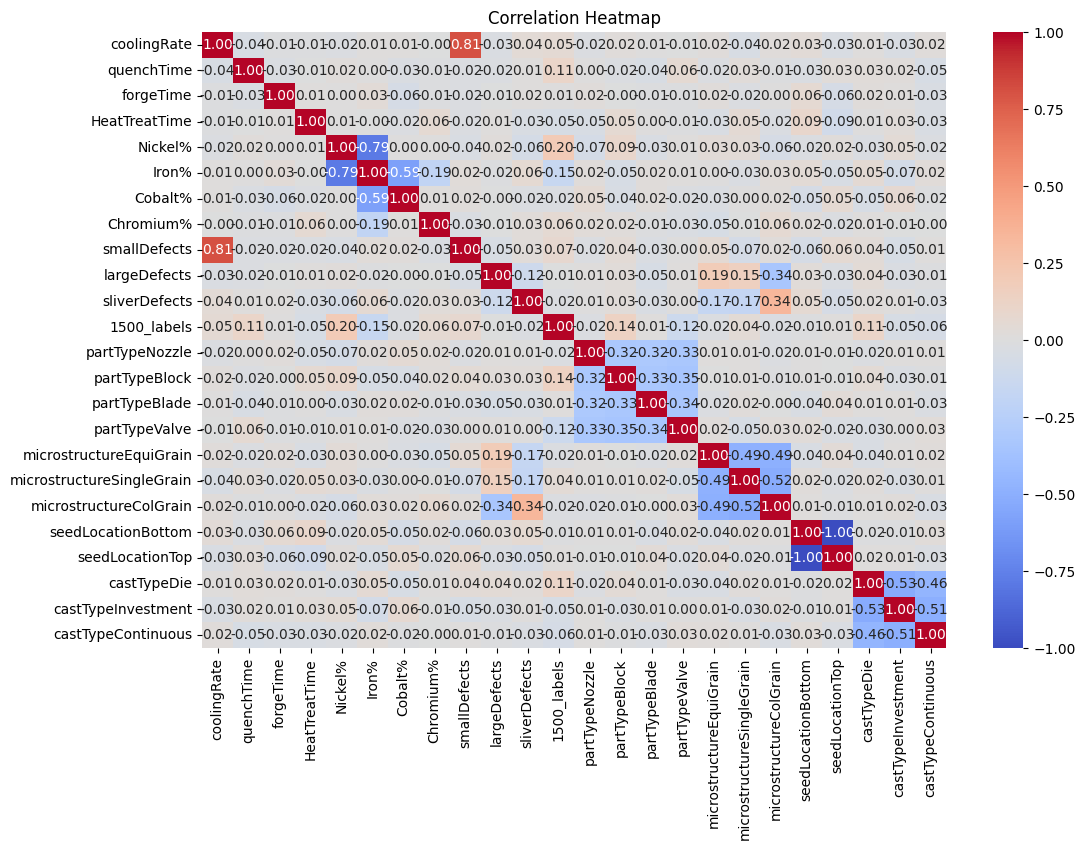

In [ ]:
c_correlation_matrix = c_enc_df_scaled.corr()
# Set the figure size
plt.figure(figsize=(12, 8))

# Create the heatmap
sns.heatmap(c_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Set the title
plt.title('Correlation Heatmap')

# Show the plot
plt.show()

##PCA for Classification

In [ ]:
c_merge = c_enc_df_scaled[['coolingRate', 'smallDefects']]


c_pca = PCA(n_components=1)  # Keeps enough components to explain 100% of the variance
c_principal_components = c_pca.fit_transform(c_merge)

# Create a DataFrame with principal components
c_df_pca = pd.DataFrame(c_principal_components, columns = [['PCA_1']])

c_enc_df_scaled = c_enc_df_scaled.drop(['coolingRate', 'smallDefects'], axis = 1)
c_enc_df_scaled['PCA_1'] = c_df_pca

#Display
print(c_enc_df_scaled.head())

   quenchTime  forgeTime  HeatTreatTime   Nickel%     Iron%   Cobalt%  \
0    0.817256   0.386215       0.987828  0.948051 -1.090327  1.012533   
1   -0.109571  -0.762366       0.859281 -1.040691  1.469374 -1.453393   
2   -1.522601  -1.584428      -1.223538 -1.453644  1.546735 -0.836912   
3   -0.572984  -1.257908      -0.586726 -0.555168 -0.166066  1.021768   
4    1.037567  -0.612551      -0.833158 -0.107658  0.382248 -0.227357   

   Chromium%  largeDefects  sliverDefects  1500_labels  ...  partTypeValve  \
0  -1.386789     -0.472752       -0.24361    -0.664020  ...      -0.600453   
1   1.124840     -0.472752       -0.24361     1.505979  ...      -0.600453   
2   0.483734      2.105896       -0.24361    -0.664020  ...      -0.600453   
3   0.008561      0.386797       -0.24361    -0.664020  ...      -0.600453   
4  -0.911616     -0.472752       -0.24361     1.505979  ...      -0.600453   

   microstructureEquiGrain  microstructureSingleGrain  microstructureColGrain  \
0          

In [ ]:
c_merge = c_enc_df_scaled[['Iron%', 'Nickel%']]


c_pca = PCA(n_components=1)  # Keeps enough components to explain 100% of the variance
c_principal_components = c_pca.fit_transform(c_merge)

# Create a DataFrame with principal components
c_df_pca = pd.DataFrame(c_principal_components, columns = [['PCA_2']])

c_enc_df_scaled = c_enc_df_scaled.drop(['Iron%', 'Nickel%'], axis = 1)
c_enc_df_scaled['PCA_2'] = c_df_pca

#Display
print(c_enc_df_scaled.head())

   quenchTime  forgeTime  HeatTreatTime   Cobalt%  Chromium%  largeDefects  \
0    0.817256   0.386215       0.987828  1.012533  -1.386789     -0.472752   
1   -0.109571  -0.762366       0.859281 -1.453393   1.124840     -0.472752   
2   -1.522601  -1.584428      -1.223538 -0.836912   0.483734      2.105896   
3   -0.572984  -1.257908      -0.586726  1.021768   0.008561      0.386797   
4    1.037567  -0.612551      -0.833158 -0.227357  -0.911616     -0.472752   

   sliverDefects  1500_labels  partTypeNozzle  partTypeBlock  ...  \
0       -0.24361    -0.664020       -0.557329      -0.581969  ...   
1       -0.24361     1.505979       -0.557329       1.718304  ...   
2       -0.24361    -0.664020        1.794271      -0.581969  ...   
3       -0.24361    -0.664020       -0.557329      -0.581969  ...   
4       -0.24361     1.505979        1.794271      -0.581969  ...   

   microstructureEquiGrain  microstructureSingleGrain  microstructureColGrain  \
0                -0.681270         

In [ ]:
c_merge = c_enc_df_scaled[['partTypeNozzle', 'partTypeBlock', 'partTypeBlade', 'partTypeValve']]


c_pca = PCA(n_components=1)  # Keeps enough components to explain 100% of the variance
c_principal_components = c_pca.fit_transform(c_merge)

# Create a DataFrame with principal components
c_df_pca = pd.DataFrame(c_principal_components, columns = [['PCA_3']])

c_enc_df_scaled = c_enc_df_scaled.drop(['partTypeNozzle', 'partTypeBlock', 'partTypeBlade', 'partTypeValve'], axis = 1)
c_enc_df_scaled['PCA_3'] = c_df_pca

#Display
print(c_enc_df_scaled.head())

   quenchTime  forgeTime  HeatTreatTime   Cobalt%  Chromium%  largeDefects  \
0    0.817256   0.386215       0.987828  1.012533  -1.386789     -0.472752   
1   -0.109571  -0.762366       0.859281 -1.453393   1.124840     -0.472752   
2   -1.522601  -1.584428      -1.223538 -0.836912   0.483734      2.105896   
3   -0.572984  -1.257908      -0.586726  1.021768   0.008561      0.386797   
4    1.037567  -0.612551      -0.833158 -0.227357  -0.911616     -0.472752   

   sliverDefects  1500_labels  microstructureEquiGrain  \
0       -0.24361    -0.664020                -0.681270   
1       -0.24361     1.505979                -0.681270   
2       -0.24361    -0.664020                -0.681270   
3       -0.24361    -0.664020                 1.467847   
4       -0.24361     1.505979                 1.467847   

   microstructureSingleGrain  microstructureColGrain  seedLocationBottom  \
0                   1.393261               -0.722544            1.006018   
1                  -0.717741  

In [ ]:
c_merge = c_enc_df_scaled[['microstructureEquiGrain', 'microstructureSingleGrain', 'microstructureColGrain']]


c_pca = PCA(n_components=1)  # Keeps enough components to explain 100% of the variance
c_principal_components = c_pca.fit_transform(c_merge)

# Create a DataFrame with principal components
c_df_pca = pd.DataFrame(c_principal_components, columns = [['PCA_4']])

c_enc_df_scaled = c_enc_df_scaled.drop(['microstructureEquiGrain', 'microstructureSingleGrain', 'microstructureColGrain'], axis = 1)
c_enc_df_scaled['PCA_4'] = c_df_pca

#Display
print(c_enc_df_scaled.head())

   quenchTime  forgeTime  HeatTreatTime   Cobalt%  Chromium%  largeDefects  \
0    0.817256   0.386215       0.987828  1.012533  -1.386789     -0.472752   
1   -0.109571  -0.762366       0.859281 -1.453393   1.124840     -0.472752   
2   -1.522601  -1.584428      -1.223538 -0.836912   0.483734      2.105896   
3   -0.572984  -1.257908      -0.586726  1.021768   0.008561      0.386797   
4    1.037567  -0.612551      -0.833158 -0.227357  -0.911616     -0.472752   

   sliverDefects  1500_labels  seedLocationBottom  seedLocationTop  \
0       -0.24361    -0.664020            1.006018        -1.006018   
1       -0.24361     1.505979            1.006018        -1.006018   
2       -0.24361    -0.664020            1.006018        -1.006018   
3       -0.24361    -0.664020           -0.994018         0.994018   
4       -0.24361     1.505979           -0.994018         0.994018   

   castTypeDie  castTypeInvestment  castTypeContinuous     PCA_1     PCA_2  \
0    -0.697054            1.3161

In [ ]:
c_merge = c_enc_df_scaled[['seedLocationBottom', 'seedLocationTop']]


c_pca = PCA(n_components=1)  # Keeps enough components to explain 100% of the variance
c_principal_components = c_pca.fit_transform(c_merge)

# Create a DataFrame with principal components
c_df_pca = pd.DataFrame(c_principal_components, columns = [['PCA_5']])

c_enc_df_scaled = c_enc_df_scaled.drop(['seedLocationBottom', 'seedLocationTop'], axis = 1)
c_enc_df_scaled['PCA_5'] = c_df_pca

#Display
print(c_enc_df_scaled.head())

   quenchTime  forgeTime  HeatTreatTime   Cobalt%  Chromium%  largeDefects  \
0    0.817256   0.386215       0.987828  1.012533  -1.386789     -0.472752   
1   -0.109571  -0.762366       0.859281 -1.453393   1.124840     -0.472752   
2   -1.522601  -1.584428      -1.223538 -0.836912   0.483734      2.105896   
3   -0.572984  -1.257908      -0.586726  1.021768   0.008561      0.386797   
4    1.037567  -0.612551      -0.833158 -0.227357  -0.911616     -0.472752   

   sliverDefects  1500_labels  castTypeDie  castTypeInvestment  \
0       -0.24361    -0.664020    -0.697054            1.316146   
1       -0.24361     1.505979    -0.697054           -0.759794   
2       -0.24361    -0.664020    -0.697054           -0.759794   
3       -0.24361    -0.664020     1.434609           -0.759794   
4       -0.24361     1.505979    -0.697054            1.316146   

   castTypeContinuous     PCA_1     PCA_2     PCA_3     PCA_4     PCA_5  
0           -0.665584 -0.859660 -1.441351 -0.544280 -1.45190

In [ ]:
c_merge = c_enc_df_scaled[['castTypeDie', 'castTypeInvestment', 'castTypeContinuous']]


c_pca = PCA(n_components=1)  # Keeps enough components to explain 100% of the variance
c_principal_components = c_pca.fit_transform(c_merge)

# Create a DataFrame with principal components
c_df_pca = pd.DataFrame(c_principal_components, columns = [['PCA_6']])

c_enc_df_scaled = c_enc_df_scaled.drop(['castTypeDie', 'castTypeInvestment', 'castTypeContinuous'], axis = 1)
c_enc_df_scaled['PCA_6'] = c_df_pca

#Display
print(c_enc_df_scaled.head())

   quenchTime  forgeTime  HeatTreatTime   Cobalt%  Chromium%  largeDefects  \
0    0.817256   0.386215       0.987828  1.012533  -1.386789     -0.472752   
1   -0.109571  -0.762366       0.859281 -1.453393   1.124840     -0.472752   
2   -1.522601  -1.584428      -1.223538 -0.836912   0.483734      2.105896   
3   -0.572984  -1.257908      -0.586726  1.021768   0.008561      0.386797   
4    1.037567  -0.612551      -0.833158 -0.227357  -0.911616     -0.472752   

   sliverDefects  1500_labels     PCA_1     PCA_2     PCA_3     PCA_4  \
0       -0.24361    -0.664020 -0.859660 -1.441351 -0.544280 -1.451902   
1       -0.24361     1.505979  0.225918  1.774884 -1.104749  1.526395   
2       -0.24361    -0.664020  1.998449  2.121588 -0.363656 -1.451902   
3       -0.24361    -0.664020 -1.814040  0.275137 -0.544280 -0.094342   
4       -0.24361     1.505979 -0.576365  0.346416 -0.363656 -0.094342   

      PCA_5     PCA_6  
0  1.422724  1.608454  
1  1.422724 -0.653673  
2  1.422724 -0.65367

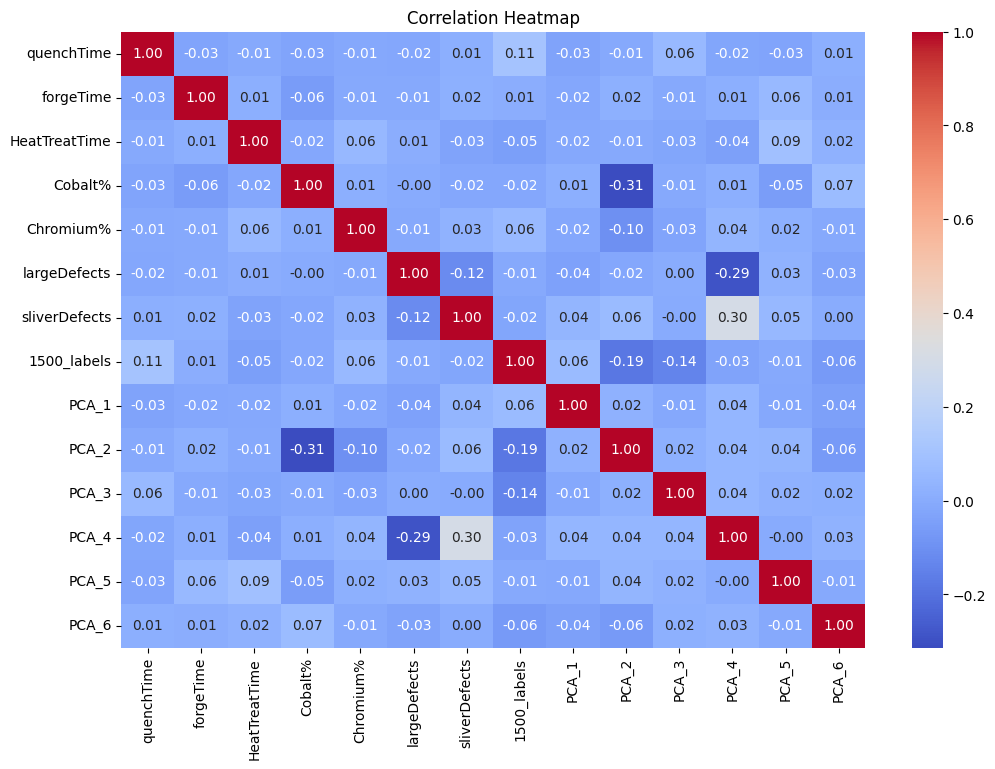

In [ ]:
c_correlation_matrix = c_enc_df_scaled.corr()
# Set the figure size
plt.figure(figsize=(12, 8))

# Create the heatmap
sns.heatmap(c_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Set the title
plt.title('Correlation Heatmap')

# Show the plot
plt.show()

In [ ]:
c_merge = c_enc_df_scaled[['Cobalt%', 'PCA_2']]


c_pca = PCA(n_components=1)  # Keeps enough components to explain 100% of the variance
c_principal_components = c_pca.fit_transform(c_merge)

# Create a DataFrame with principal components
c_df_pca = pd.DataFrame(c_principal_components, columns = [['PCA_C_2']])

c_enc_df_scaled = c_enc_df_scaled.drop(['Cobalt%', 'PCA_2'], axis = 1)
c_enc_df_scaled['PCA_C_2'] = c_df_pca

#Display
print(c_enc_df_scaled.head())

   quenchTime  forgeTime  HeatTreatTime  Chromium%  largeDefects  \
0    0.817256   0.386215       0.987828  -1.386789     -0.472752   
1   -0.109571  -0.762366       0.859281   1.124840     -0.472752   
2   -1.522601  -1.584428      -1.223538   0.483734      2.105896   
3   -0.572984  -1.257908      -0.586726   0.008561      0.386797   
4    1.037567  -0.612551      -0.833158  -0.911616     -0.472752   

   sliverDefects  1500_labels     PCA_1     PCA_3     PCA_4     PCA_5  \
0       -0.24361    -0.664020 -0.859660 -0.544280 -1.451902  1.422724   
1       -0.24361     1.505979  0.225918 -1.104749  1.526395  1.422724   
2       -0.24361    -0.664020  1.998449 -0.363656 -1.451902  1.422724   
3       -0.24361    -0.664020 -1.814040 -0.544280 -0.094342 -1.405754   
4       -0.24361     1.505979 -0.576365 -0.363656 -0.094342 -1.405754   

      PCA_6   PCA_C_2  
0  1.608454 -1.724984  
1 -0.653673  2.206213  
2 -0.653673  2.279464  
3 -1.186595 -0.153440  
4  1.608454  0.408230  


In [ ]:
c_merge = c_enc_df_scaled[['sliverDefects', 'PCA_4']]


c_pca = PCA(n_components=1)  # Keeps enough components to explain 100% of the variance
c_principal_components = c_pca.fit_transform(c_merge)

# Create a DataFrame with principal components
c_df_pca = pd.DataFrame(c_principal_components, columns = [['PCA_s_4']])

c_enc_df_scaled = c_enc_df_scaled.drop(['sliverDefects', 'PCA_4'], axis = 1)
c_enc_df_scaled['PCA_s_4'] = c_df_pca

#Display
print(c_enc_df_scaled.head())

   quenchTime  forgeTime  HeatTreatTime  Chromium%  largeDefects  1500_labels  \
0    0.817256   0.386215       0.987828  -1.386789     -0.472752    -0.664020   
1   -0.109571  -0.762366       0.859281   1.124840     -0.472752     1.505979   
2   -1.522601  -1.584428      -1.223538   0.483734      2.105896    -0.664020   
3   -0.572984  -1.257908      -0.586726   0.008561      0.386797    -0.664020   
4    1.037567  -0.612551      -0.833158  -0.911616     -0.472752     1.505979   

      PCA_1     PCA_3     PCA_5     PCA_6   PCA_C_2   PCA_s_4  
0 -0.859660 -0.544280  1.422724  1.608454 -1.724984 -1.399920  
1  0.225918 -1.104749  1.422724 -0.653673  2.206213  1.240593  
2  1.998449 -0.363656  1.422724 -0.653673  2.279464 -1.399920  
3 -1.814040 -0.544280 -1.405754 -1.186595 -0.153440 -0.196328  
4 -0.576365 -0.363656 -1.405754  1.608454  0.408230 -0.196328  


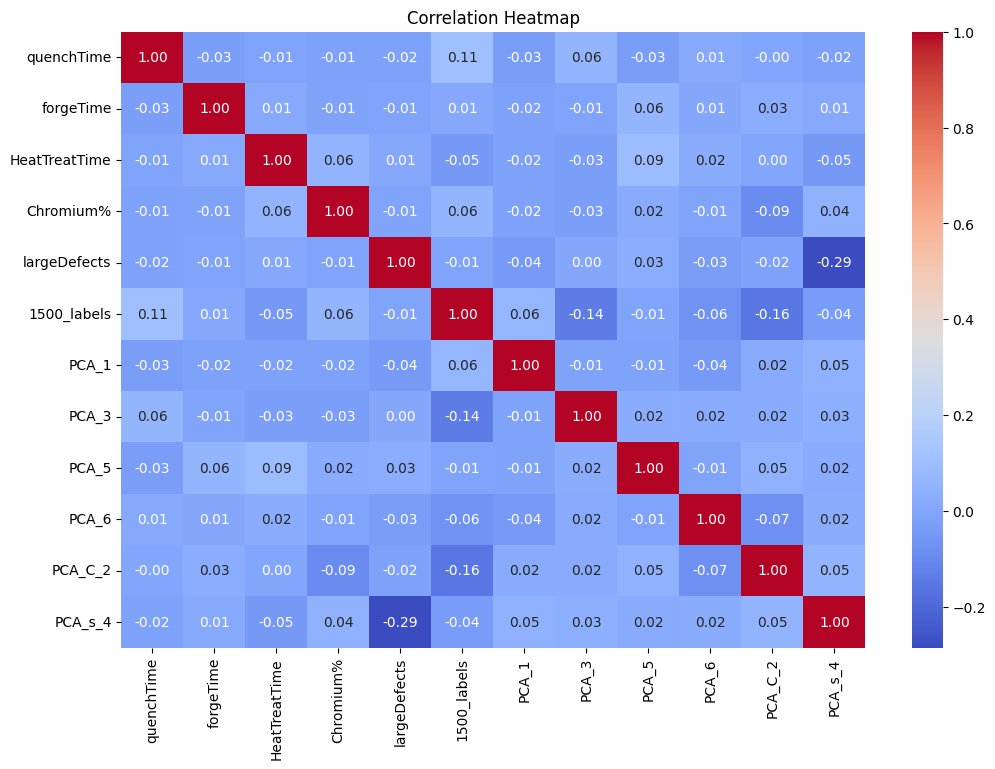

In [ ]:
c_correlation_matrix = c_enc_df_scaled.corr()
# Set the figure size
plt.figure(figsize=(12, 8))

# Create the heatmap
sns.heatmap(c_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Set the title
plt.title('Correlation Heatmap')

# Show the plot
plt.show()

##Classification

In [ ]:
# Independent variables
X = c_enc_df_scaled[['quenchTime', 'PCA_3', 'PCA_C_2']]

# Dependent variable
Y = c_enc_df_scaled['1500_labels']

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [ ]:
# Import KBinsDiscretizer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.linear_model import LogisticRegression

# Create a discretizer object
discretizer = KBinsDiscretizer(n_bins=2, encode='ordinal', strategy='uniform')
y_train_discretized = discretizer.fit_transform(y_train.values.reshape(-1, 1))
y_train_discretized = y_train_discretized.ravel()


# Define the Logistic Regression model
logreg = LogisticRegression(random_state=42)
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
}
grid_search = GridSearchCV(estimator=logreg, param_grid=param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train_discretized)

# Get the best model and evaluate it on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Best Parameters:", grid_search.best_params_)


# Get the best model and evaluate it on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

y_test_discretized = discretizer.transform(y_test.values.reshape(-1, 1))
y_test_discretized = y_test_discretized.ravel()

print("Predictions:", y_pred)

from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test_discretized, y_pred)
print("Accuracy:", accuracy)
report = classification_report(y_test_discretized, y_pred)
print("Classification Report:\n", report)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}
Predictions: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]
Accuracy: 0.72
Classification Report:
               precision    recall  f1-score   support

         0.0       0.74      0.95      0.83       145
         1.0       0.46      0.11      0.18        55

    accuracy                           0.72      

In [ ]:
import xgboost as xgb

# Define the XGBoost classifier
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss")
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    verbose=1,
    n_jobs=-1
)
y_train_binary = y_train_discretized
grid_search.fit(X_train, y_train_binary)
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Use the best model to make predictions on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_test_binary = y_test_discretized

# Accuracy and Classification report using binary labels
accuracy = accuracy_score(y_test_binary, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:")
print(classification_report(y_test_binary, y_pred))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 150, 'subsample': 1.0}
Best Cross-Validation Accuracy: 0.69125
Accuracy: 0.725
Classification Report:
              precision    recall  f1-score   support

         0.0       0.72      1.00      0.84       145
         1.0       0.00      0.00      0.00        55

    accuracy                           0.72       200
   macro avg       0.36      0.50      0.42       200
weighted avg       0.53      0.72      0.61       200



/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [22:36:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in 